# HR Employee Attrition & Flight Risk Predictive Model
**Objective:** Predict high-risk employees before they leave using dynamic ensemble learning, handling severe class imbalance through SMOTE, and providing conditional risk tiering.

### 1. Environment Setup & Data Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, make_scorer
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

print("✅ Essential libraries configured.")

✅ Essential libraries configured.


In [2]:
url = "https://raw.githubusercontent.com/nelson-wu/employee-attrition-ml/master/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

# Initialize dataset consistency split
train_df, validate_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Attrition']
)

train_df.to_csv('train_hr_data.csv', index=False)
validate_df.to_csv('validate_hr_data.csv', index=False)

print(f"Primary Training Records: {train_df.shape[0]}")
print(f"Secondary Validation Records: {validate_df.shape[0]}")

Primary Training Records: 1176
Secondary Validation Records: 294


### 2. Feature Engineering System
Deriving sophisticated engagement and interaction features to capture complex behavioral indicators of attrition.

In [3]:
def engineer_features(df):
    df = df.copy()

    # Fix static column values
    if 'Attrition' in df.columns and df['Attrition'].dtype == object:
        df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

    df.drop(columns=[c for c in ['EmployeeCount', 'Over18', 'StandardHours'] if c in df.columns], inplace=True)

    # Ratio and Flag Interactions
    df['IncomePerYear']         = df['MonthlyIncome'] / (df['YearsAtCompany'] + 1)
    df['SatisfactionScore']     = (df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction']) / 3
    df['WorkLifeStress']        = df['WorkLifeBalance'] * df['JobInvolvement']
    df['CareerGrowthRate']      = df['JobLevel'] / (df['YearsAtCompany'] + 1)
    df['PromotionLag']          = df['YearsAtCompany'] - df['YearsSinceLastPromotion']
    df['TenureRatio']           = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)
    df['OvertimeFlag']          = (df['OverTime'] == 'Yes').astype(int)
    df['LowSatisfactionFlag']   = ((df['JobSatisfaction'] <= 2) | (df['EnvironmentSatisfaction'] <= 2)).astype(int)
    df['YoungAndFarFlag']       = ((df['Age'] < 30) & (df['DistanceFromHome'] > 10)).astype(int)
    df['StockRiskFlag']         = (df['StockOptionLevel'] == 0).astype(int)
    df['TotalExperience']       = df['TotalWorkingYears'] - df['YearsAtCompany']
    df['IncomeToLevelRatio']    = df['MonthlyIncome'] / (df['JobLevel'] + 1)

    return df

train_df = engineer_features(train_df)
validate_df = engineer_features(validate_df)
print(f"Expanded Feature Matrix: {train_df.shape[1]} Dimensions")

Expanded Feature Matrix: 44 Dimensions


### 3. Exploratory Data Analysis
Visualizing attrition correlations to confirm signal extraction.

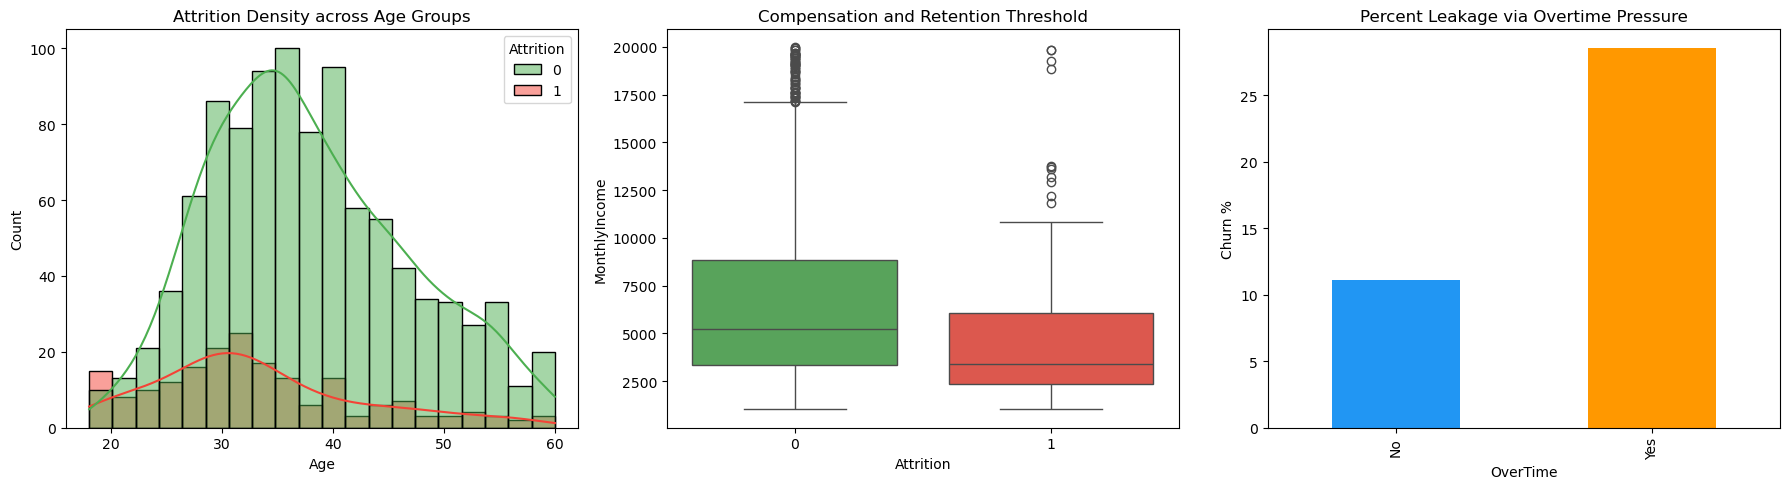

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=train_df, x='Age', hue='Attrition', bins=20, kde=True, ax=axes[0], palette={0: '#4CAF50', 1: '#F44336'})
axes[0].set_title("Attrition Density across Age Groups")

sns.boxplot(data=train_df, x='Attrition', y='MonthlyIncome', hue='Attrition', ax=axes[1], palette={0: '#4CAF50', 1: '#F44336'}, legend=False)
axes[1].set_title("Compensation and Retention Threshold")

ot_rate = train_df.groupby('OverTime')['Attrition'].mean() * 100
ot_rate.plot(kind='bar', ax=axes[2], color=['#2196F3', '#FF9800'])
axes[2].set_title("Percent Leakage via Overtime Pressure")
axes[2].set_ylabel("Churn %")

plt.tight_layout()
plt.show()

### 4. Data Transformation & Balancing Pipeline

In [5]:
X = train_df.drop(columns=['Attrition', 'EmployeeNumber'])
y = train_df['Attrition']
X_v = validate_df.drop(columns=['Attrition', 'EmployeeNumber'])
y_v = validate_df['Attrition']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)
X_val_p   = preprocessor.transform(X_v)

print(f"Imbalance Check - Baseline Attrition Ratio: {y_train.mean()*100:.1f}%")
sm = SMOTE(random_state=42)
X_train_b, y_train_b = sm.fit_resample(X_train_p, y_train)
print(f"SMOTE Complete - Synthetic Retention Re-equalized ({len(y_train_b)} total samples)")

Imbalance Check - Baseline Attrition Ratio: 16.2%


SMOTE Complete - Synthetic Retention Re-equalized (1576 total samples)


### 5. Ensemble Architecture & Hyperparameter Strategy

In [6]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
lr = LogisticRegression(max_iter=3000, C=0.5, class_weight='balanced', random_state=42, solver='saga')
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', random_state=42, scale_pos_weight=1)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('lr', lr), ('xgb', xgb), ('gb', gb)],
    voting='soft', 
    weights=[3, 1, 3, 2]
)

print("Fitting Ensemble components to balanced vector space...")
ensemble.fit(X_train_b, y_train_b)
print("✅ Ensemble Construction Succeeded.")

Fitting Ensemble components to balanced vector space...


✅ Ensemble Construction Succeeded.


### 6. 5-Fold Stratified Cross-Validation
Validating consistency across diverse data splits.

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Recombine for full CV run across standard preprocessed set (not oversampled for pure metrics test)
X_combined = np.vstack([X_train_p, X_test_p])
y_combined = np.concatenate([y_train, y_test])

f1_scores = cross_val_score(ensemble, X_combined, y_combined, cv=skf, scoring='f1', n_jobs=-1)
auc_scores = cross_val_score(ensemble, X_combined, y_combined, cv=skf, scoring='roc_auc', n_jobs=-1)

print("=== 5-Fold Stratified Results ===")
print(f"Mean F1 Score : {f1_scores.mean():.3f} (+/- {f1_scores.std()*2:.3f})")
print(f"Mean ROC-AUC  : {auc_scores.mean():.3f} (+/- {auc_scores.std()*2:.3f})")

=== 5-Fold Stratified Results ===
Mean F1 Score : 0.464 (+/- 0.101)
Mean ROC-AUC  : 0.824 (+/- 0.048)


### 7. Performance Evaluation (Smart Threshold: 0.35)

--- Detailed Metrics (Threshold = 0.35) ---
Precision : 0.5135
Recall    : 0.5000
F1 Score  : 0.5067
ROC-AUC   : 0.8114

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       198
           1       0.51      0.50      0.51        38

    accuracy                           0.84       236
   macro avg       0.71      0.70      0.71       236
weighted avg       0.84      0.84      0.84       236



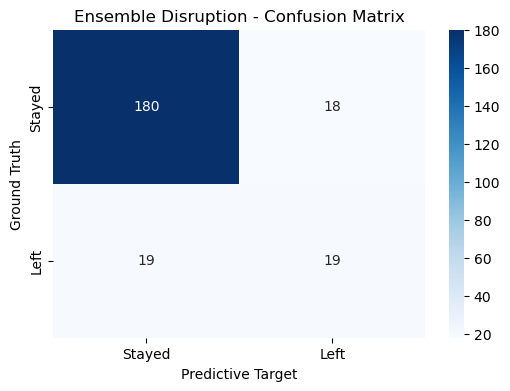

In [8]:
threshold = 0.35
test_probs = ensemble.predict_proba(X_test_p)[:, 1]
test_preds = (test_probs >= threshold).astype(int)

print(f"--- Detailed Metrics (Threshold = {threshold}) ---")
print(f"Precision : {precision_score(y_test, test_preds):.4f}")
print(f"Recall    : {recall_score(y_test, test_preds):.4f}")
print(f"F1 Score  : {f1_score(y_test, test_preds):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, test_probs):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_preds))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title("Ensemble Disruption - Confusion Matrix")
plt.ylabel("Ground Truth")
plt.xlabel("Predictive Target")
plt.show()

### 8. Global Determinants (Feature Importance)

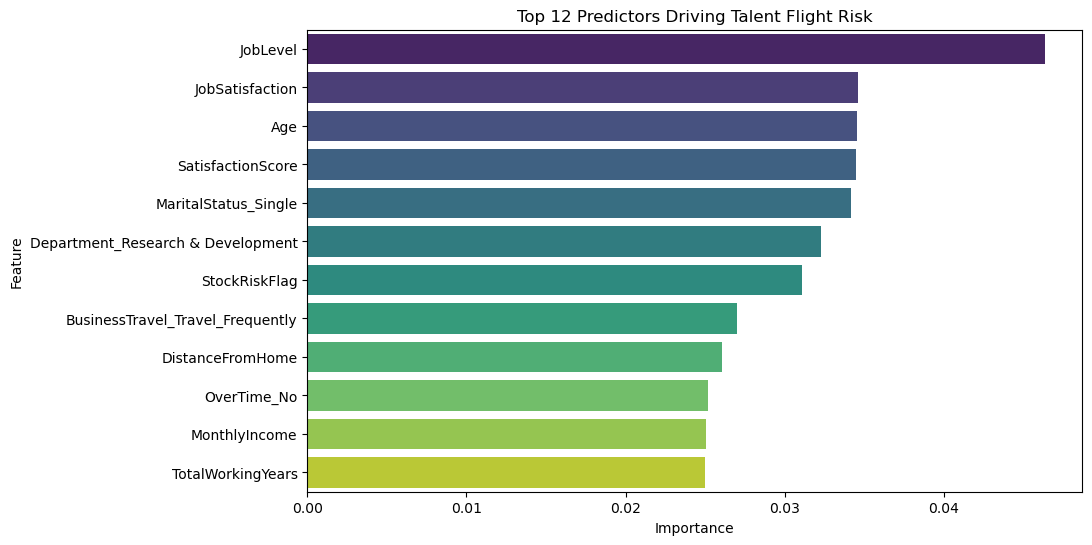

In [9]:
# Extract fit names
cat_feat = list(preprocessor.named_transformers_['cat'].named_steps['oh'].get_feature_names_out(cat_cols))
all_feat = num_cols + cat_feat

# Extracting from base learner Random Forest
fi = pd.DataFrame({
    'Feature': all_feat,
    'Importance': ensemble.named_estimators_['rf'].feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi, x='Importance', y='Feature', palette='viridis')
plt.title("Top 12 Predictors Driving Talent Flight Risk")
plt.show()

### 9. Strategic HR Intelligence Injection (Excel Deployment)

In [10]:
final_prob = ensemble.predict_proba(X_val_p)[:, 1]
final_class = (final_prob >= 0.35).astype(int)

out_df = pd.DataFrame({
    'EmployeeNumber'   : validate_df['EmployeeNumber'],
    'Risk_Probability' : (final_prob * 100).round(2),
    'Risk_Level'       : pd.cut(final_prob, bins=[0, 0.35, 0.6, 1.0], labels=['Low Risk', 'Medium Risk', 'High Risk']),
    'Needs_Intervention': final_class
})

path = 'retention_risk_report.xlsx'
out_df.to_excel(path, index=False)

wb = load_workbook(path)
ws = wb.active
fills = {
    'High Risk': PatternFill(start_color="FF6B6B", end_color="FF6B6B", fill_type="solid"),
    'Medium Risk': PatternFill(start_color="FFD93D", end_color="FFD93D", fill_type="solid"),
    'Low Risk': PatternFill(start_color="6BCB77", end_color="6BCB77", fill_type="solid")
}

for r in range(2, ws.max_row + 1):
    risk = ws[f'C{r}'].value
    if risk in fills:
        for c in ['A', 'B', 'C', 'D']: ws[f'{c}{r}'].fill = fills[risk]

wb.save(path)
print(f"✅ Strategic actionable risk intelligence generated in '{path}'.")
print(f"Detected {final_class.sum()} dynamic intervention targets within the validated sector.")

✅ Strategic actionable risk intelligence generated in 'retention_risk_report.xlsx'.
Detected 37 dynamic intervention targets within the validated sector.
